In [ ]:
# ===== STEP 1: setup =====
!pip -q install combat umap-learn imbalanced-learn lime shap gseapy

import os, random, warnings, numpy as np
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)

# ---- your Drive folder ----
DATA_DIR = "/content/drive/MyDrive/lungxi_Datasets"

FILES = {
    "GSE10072": "1_Final_dataset_GSE10072_transposed.csv",
    "GSE27262": "2_Final_dataset_GSE27262_transposed.csv",
    "GSE30219": "3_Final_dataset_GSE30219_transposed.csv",
    "GSE31210": "4_Final_dataset_GSE31210_transposed.csv",
    "GSE33479": "5_Final_dataset_GSE33479_transposed.csv",
    "GSE68465": "6_Final_dataset_GSE68465_transposed.csv",
    "ICGC":     "7_Prepared_Data_2_ICGC__A-N_Final.csv",
    "TCGA":     "8_Prepared_Data_1_TCGA__A-S-N_Final.csv",
}
CLASSES   = ["A", "N", "S"]                  # A=adenocarcinoma, N=normal, S=squamous
CLASS_IDX = {c: i for i, c in enumerate(CLASSES)}
N_PCA, EPOCHS, BATCH, TOPK = 256, 60, 64, 100
LIME_PER_FOLD, SHAP_BG = 60, 100

from google.colab import drive
drive.mount("/content/drive")

assert os.path.isdir(DATA_DIR), f"DATA_DIR not found: {DATA_DIR}"
missing = [f for f in FILES.values() if not os.path.isfile(os.path.join(DATA_DIR, f))]
print("Missing files:", missing if missing else "none — all 8 found ✓")
print("GPU:", tf.config.list_physical_devices('GPU'))

  Preparing metadata (setup.py) ... done
Mounted at /content/drive
Missing files: none — all 8 found ✓
GPU: []


**2**

In [ ]:
# ===== STEP 2: load, intersect genes, merge, and save =====
import pandas as pd, functools

paths = {k: os.path.join(DATA_DIR, v) for k, v in FILES.items()}

# a) common gene set from headers only (fast, low memory)
def header_genes(p):
    cols = [c.strip() for c in pd.read_csv(p, nrows=0).columns]
    return set(cols) - {"Sample_ID", "Condition"}

gene_sets    = {k: header_genes(p) for k, p in paths.items()}
common_genes = sorted(functools.reduce(lambda a, b: a & b, gene_sets.values()))
print("common genes across 8 cohorts:", len(common_genes))   # expect 11519

# b) load each cohort keeping only common genes + labels
keep = set(common_genes) | {"Sample_ID", "Condition"}
def load_cohort(name, p):
    df = pd.read_csv(p, usecols=lambda c: c.strip() in keep)
    df.columns = df.columns.str.strip()
    df["Condition"] = df["Condition"].astype(str).str.strip()
    df["Cohort"] = name
    return df

frames = []
for k, p in paths.items():
    df = load_cohort(k, p)
    print(f"  loaded {k:9s} {df.shape[0]:5d} samples")
    frames.append(df)

merged    = pd.concat(frames, axis=0, ignore_index=True)
meta_cols = ["Sample_ID", "Cohort", "Condition"]
merged    = merged[meta_cols + common_genes]

# numeric coercion + fill occasional missing values with per-gene median
X = merged[common_genes].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median(numeric_only=True))
merged[common_genes] = X

print("\nmerged shape:", merged.shape, " (rows = samples, cols = 3 meta + genes)")
print("NaNs remaining:", int(merged[common_genes].isna().sum().sum()))
print("\nclass × cohort table:")
print(pd.crosstab(merged.Cohort, merged.Condition, margins=True))

# c) save the merged dataset (CSV + parquet) so you never redo the intersection
out_dir = os.path.join(DATA_DIR, "pipeline_outputs")
os.makedirs(out_dir, exist_ok=True)

csv_path = os.path.join(out_dir, "merged_11519genes.csv")
merged.to_csv(csv_path, index=False)
print("\nsaved CSV    :", csv_path, "|", round(os.path.getsize(csv_path)/1e6, 1), "MB")

pq_path = os.path.join(out_dir, "merged_11519genes.parquet")
merged.to_parquet(pq_path, index=False)
print("saved parquet:", pq_path, "|", round(os.path.getsize(pq_path)/1e6, 1), "MB")

common genes across 8 cohorts: 11519
  loaded GSE10072    107 samples
  loaded GSE27262     50 samples
  loaded GSE30219    307 samples
  loaded GSE31210    246 samples
  loaded GSE33479    122 samples
  loaded GSE68465    462 samples
  loaded ICGC        543 samples
  loaded TCGA       1153 samples

merged shape: (2990, 11522)  (rows = samples, cols = 3 meta + genes)
NaNs remaining: 0

class × cohort table:
Condition     A    N    S   All
Cohort                         
GSE10072     58   49    0   107
GSE27262     25   25    0    50
GSE30219      0   14  293   307
GSE31210    246    0    0   246
GSE33479      0   27   95   122
GSE68465    443   19    0   462
ICGC        488   55    0   543
TCGA        541  110  502  1153
All        1801  299  890  2990

saved CSV    : /content/drive/MyDrive/lungxi_Datasets/pipeline_outputs/merged_11519genes.csv | 273.3 MB
saved parquet: /content/drive/MyDrive/lungxi_Datasets/pipeline_outputs/merged_11519genes.parquet | 307.4 MB


3. Combat

In [ ]:
# ===== re-run after restart: redefine config + mount =====
import os, random, warnings, numpy as np
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)

DATA_DIR = "/content/drive/MyDrive/lungxi_Datasets"

FILES = {
    "GSE10072": "1_Final_dataset_GSE10072_transposed.csv",
    "GSE27262": "2_Final_dataset_GSE27262_transposed.csv",
    "GSE30219": "3_Final_dataset_GSE30219_transposed.csv",
    "GSE31210": "4_Final_dataset_GSE31210_transposed.csv",
    "GSE33479": "5_Final_dataset_GSE33479_transposed.csv",
    "GSE68465": "6_Final_dataset_GSE68465_transposed.csv",
    "ICGC":     "7_Prepared_Data_2_ICGC__A-N_Final.csv",
    "TCGA":     "8_Prepared_Data_1_TCGA__A-S-N_Final.csv",
}
CLASSES   = ["A", "N", "S"]
CLASS_IDX = {c: i for i, c in enumerate(CLASSES)}
N_PCA, EPOCHS, BATCH, TOPK = 256, 60, 64, 100
LIME_PER_FOLD, SHAP_BG = 60, 100

from google.colab import drive
drive.mount("/content/drive")
assert os.path.isdir(DATA_DIR), f"DATA_DIR not found: {DATA_DIR}"
print("config restored ✓")

Mounted at /content/drive
config restored ✓


In [ ]:
import pandas as pd
merged = pd.read_parquet(os.path.join(DATA_DIR, "pipeline_outputs", "merged_11519genes.parquet"))
common_genes = [c for c in merged.columns if c not in ("Sample_ID", "Cohort", "Condition")]
print("reloaded:", merged.shape, "| genes:", len(common_genes))

reloaded: (2990, 11522) | genes: 11519


In [ ]:
# ===== STEP 3: per-cohort log2 (auto) + ComBat correction (self-contained) =====

# --- 3a) log2 only the cohorts on a linear scale ---
Xarr    = merged[common_genes].to_numpy(dtype="float32", copy=True)   # writable array
cohorts = merged["Cohort"].to_numpy()
for name in FILES:
    m = cohorts == name
    block = Xarr[m]
    mx = float(np.nanmax(block))
    if mx > 30:
        Xarr[m] = np.log2(np.clip(block, 0, None) + 1.0)
        print(f"{name:9s} max={mx:10.1f}  -> log2(x+1) applied")
    else:
        print(f"{name:9s} max={mx:10.2f}  -> already log-scale (kept)")
merged[common_genes] = Xarr
print("log2 step done\n")

# --- 3b) drop genes constant within any single cohort ---
grp = merged.groupby("Cohort")[common_genes].std()
bad = grp.columns[(grp == 0).any(axis=0)].tolist()
GENES = [g for g in common_genes if g not in set(bad)]
print(f"dropped {len(bad)} genes constant within >=1 cohort; genes kept: {len(GENES)}")

# --- 3c) ComBat implementation (parametric empirical Bayes, Johnson et al. 2007) ---
def combat(data, batch):
    """data: genes x samples (DataFrame). batch: array-like length n_samples."""
    X = data.values.astype(float)
    batch = np.asarray(batch)
    levels = np.unique(batch)

    gmean = X.mean(1, keepdims=True)
    gvar  = X.var(1, keepdims=True); gvar[gvar == 0] = 1e-8
    Z = (X - gmean) / np.sqrt(gvar)

    def aprior(g): m = g.mean(1); s2 = g.var(1); s2[s2==0]=1e-8; return (2*s2 + m**2) / s2
    def bprior(g): m = g.mean(1); s2 = g.var(1); s2[s2==0]=1e-8; return (m*s2 + m**3) / s2

    corrected = Z.copy()
    for lv in levels:
        idx = np.where(batch == lv)[0]
        sub = Z[:, idx]; n = sub.shape[1]
        gamma_hat = sub.mean(1)
        delta_hat = sub.var(1); delta_hat[delta_hat == 0] = 1e-8
        gbar, t2 = gamma_hat.mean(), gamma_hat.var()
        a, b = aprior(sub), bprior(sub)
        g_star, d_star = gamma_hat.copy(), delta_hat.copy()
        for _ in range(30):
            g_new = (n*t2*g_star + d_star*gbar) / (n*t2 + d_star)
            resid = sub - g_new[:, None]
            d_new = (0.5*(resid**2).sum(1) + b) / (n/2.0 + a - 1.0)
            if max(np.max(np.abs(g_new-g_star)), np.max(np.abs(d_new-d_star))) < 1e-4:
                g_star, d_star = g_new, d_new; break
            g_star, d_star = g_new, d_new
        corrected[:, idx] = (sub - g_star[:, None]) / np.sqrt(d_star)[:, None]

    out = corrected * np.sqrt(gvar) + gmean
    return pd.DataFrame(out, index=data.index, columns=data.columns)

expr = merged[GENES].T
corrected = combat(expr, merged["Cohort"].values).T
corrected.index = merged.index

merged_corr = pd.concat(
    [merged[["Sample_ID", "Cohort", "Condition"]].reset_index(drop=True),
     corrected.reset_index(drop=True)], axis=1)

nan_before = int(merged_corr[GENES].isna().sum().sum())
merged_corr[GENES] = merged_corr[GENES].fillna(0.0)
print("ComBat done. corrected shape:", corrected.shape, "| NaNs filled:", nan_before)

# --- 3d) save ---
out_dir = os.path.join(DATA_DIR, "pipeline_outputs")
cpath = os.path.join(out_dir, "merged_combat_corrected.parquet")
merged_corr.to_parquet(cpath, index=False)
print("saved:", cpath, "|", round(os.path.getsize(cpath)/1e6, 1), "MB")

GSE10072  max=     14.79  -> already log-scale (kept)
GSE27262  max=    1381.4  -> log2(x+1) applied
GSE30219  max=     14.61  -> already log-scale (kept)
GSE31210  max=   43275.6  -> log2(x+1) applied
GSE33479  max=    2559.4  -> log2(x+1) applied
GSE68465  max=  110790.0  -> log2(x+1) applied
ICGC      max= 4980062.0  -> log2(x+1) applied
TCGA      max=  121625.5  -> log2(x+1) applied
log2 step done

dropped 25 genes constant within >=1 cohort; genes kept: 11494
ComBat done. corrected shape: (2990, 11494) | NaNs filled: 4866295
saved: /content/drive/MyDrive/lungxi_Datasets/pipeline_outputs/merged_combat_corrected.parquet | 270.3 MB


In [ ]:
import pandas as pd
merged = pd.read_parquet(os.path.join(DATA_DIR, "pipeline_outputs", "merged_11519genes.parquet"))
common_genes = [c for c in merged.columns if c not in ("Sample_ID", "Cohort", "Condition")]
print("reloaded clean:", merged.shape, "| genes:", len(common_genes))

reloaded clean: (2990, 11522) | genes: 11519


In [ ]:
# ===== STEP 3 (FIXED): per-cohort log2 + correct ComBat =====

# --- 3a) log2 only linear-scale cohorts ---
Xarr    = merged[common_genes].to_numpy(dtype="float32", copy=True)
cohorts = merged["Cohort"].to_numpy()
for name in FILES:
    m = cohorts == name
    mx = float(np.nanmax(Xarr[m]))
    if mx > 30:
        Xarr[m] = np.log2(np.clip(Xarr[m], 0, None) + 1.0)
        print(f"{name:9s} max={mx:12.1f} -> log2(x+1)")
    else:
        print(f"{name:9s} max={mx:12.2f} -> kept")
merged[common_genes] = Xarr
print("log2 done\n")

# --- 3b) drop genes constant within any cohort ---
grp = merged.groupby("Cohort")[common_genes].std()
bad = grp.columns[(grp == 0).any(axis=0)].tolist()
GENES = [g for g in common_genes if g not in set(bad)]
print(f"dropped {len(bad)} constant genes; kept {len(GENES)}")

# --- 3c) correct parametric ComBat (Johnson et al. 2007) ---
def combat(data, batch):
    """data: genes x samples DataFrame; batch: length n_samples."""
    X = data.values.astype(float)
    batch = np.asarray(batch)
    gmean = X.mean(1, keepdims=True)
    gvar  = X.var(1, keepdims=True); gvar[gvar < 1e-8] = 1e-8
    Z = (X - gmean) / np.sqrt(gvar)
    corrected = Z.copy()
    for lv in np.unique(batch):
        idx = np.where(batch == lv)[0]
        sub = Z[:, idx]; n = sub.shape[1]
        gamma_hat = sub.mean(1)                       # per-gene additive
        delta_hat = sub.var(1); delta_hat[delta_hat < 1e-8] = 1e-8   # per-gene mult.
        gbar = gamma_hat.mean(); tau2 = gamma_hat.var()
        # SCALAR priors from distribution of delta_hat across genes (the fix)
        Dbar = delta_hat.mean(); S2 = delta_hat.var()
        S2 = max(S2, 1e-8)
        a_prior = (2*S2 + Dbar**2) / S2               # scalar > 2
        b_prior = (Dbar*S2 + Dbar**3) / S2            # scalar > 0
        g_star, d_star = gamma_hat.copy(), delta_hat.copy()
        for _ in range(50):
            g_new = (n*tau2*gamma_hat + d_star*gbar) / (n*tau2 + d_star)
            resid = sub - g_new[:, None]
            d_new = (0.5*(resid**2).sum(1) + b_prior) / (n/2.0 + a_prior - 1.0)
            if max(np.max(np.abs(g_new-g_star)), np.max(np.abs(d_new-d_star))) < 1e-4:
                g_star, d_star = g_new, d_new; break
            g_star, d_star = g_new, d_new
        corrected[:, idx] = (sub - g_star[:, None]) / np.sqrt(d_star)[:, None]
    out = corrected * np.sqrt(gvar) + gmean
    return pd.DataFrame(out, index=data.index, columns=data.columns)

corrected = combat(merged[GENES].T, merged["Cohort"].values).T
corrected.index = merged.index
merged_corr = pd.concat(
    [merged[["Sample_ID","Cohort","Condition"]].reset_index(drop=True),
     corrected.reset_index(drop=True)], axis=1)

nan_ct = int(merged_corr[GENES].isna().sum().sum())
merged_corr[GENES] = merged_corr[GENES].fillna(0.0)
print(f"ComBat done. shape {corrected.shape} | NaNs: {nan_ct}")

# --- 3d) save ---
cpath = os.path.join(DATA_DIR, "pipeline_outputs", "merged_combat_corrected.parquet")
merged_corr.to_parquet(cpath, index=False)
print("saved:", cpath, "|", round(os.path.getsize(cpath)/1e6,1), "MB")

GSE10072  max=       14.79 -> kept
GSE27262  max=      1381.4 -> log2(x+1)
GSE30219  max=       14.61 -> kept
GSE31210  max=     43275.6 -> log2(x+1)
GSE33479  max=      2559.4 -> log2(x+1)
GSE68465  max=    110790.0 -> log2(x+1)
ICGC      max=   4980062.0 -> log2(x+1)
TCGA      max=    121625.5 -> log2(x+1)
log2 done

dropped 25 constant genes; kept 11494
ComBat done. shape (2990, 11494) | NaNs: 0
saved: /content/drive/MyDrive/lungxi_Datasets/pipeline_outputs/merged_combat_corrected.parquet | 310.9 MB


computing UMAP (before)…
computing UMAP (after)…

--- silhouette (cluster tightness by label) ---
by COHORT    before=+0.754  after=-0.118   (want LOWER after)
by CONDITION before=+0.017  after=+0.164   (want maintained/higher)


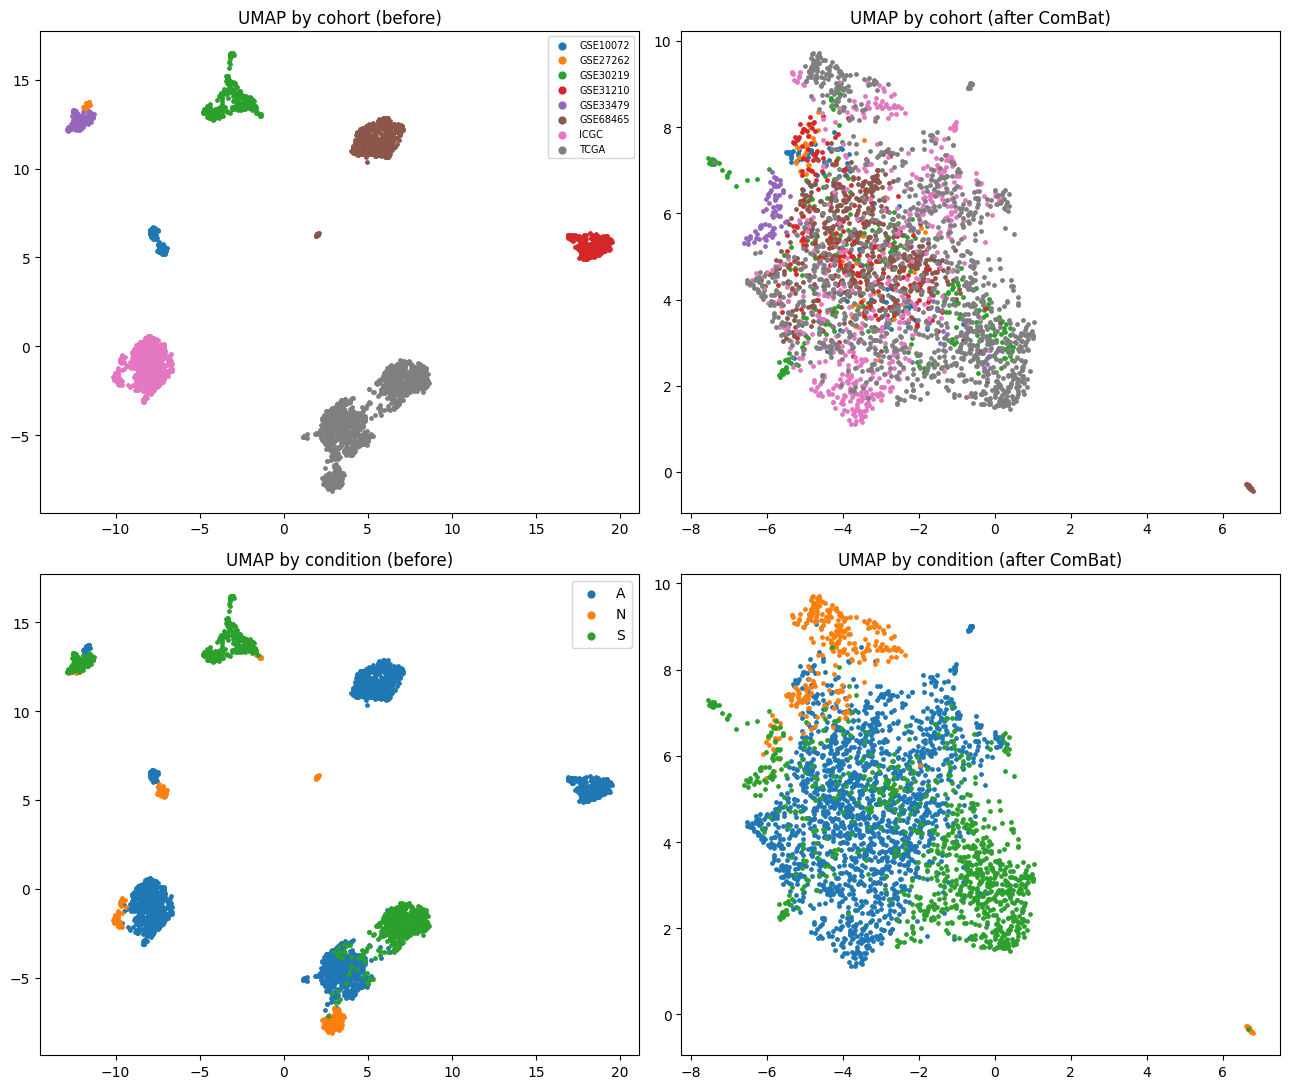

In [ ]:
# ===== STEP 4: verify correction — UMAP + silhouette =====
import umap, matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# reload pre-correction (log2 but no ComBat) for the "before" picture
pre = pd.read_parquet(os.path.join(DATA_DIR, "pipeline_outputs", "merged_11519genes.parquet"))
# apply the same log2 so before/after differ ONLY by ComBat
Xpre = pre[common_genes].to_numpy(dtype="float32", copy=True)
cohorts = pre["Cohort"].to_numpy()
for name in FILES:
    m = cohorts == name
    if float(np.nanmax(Xpre[m])) > 30:
        Xpre[m] = np.log2(np.clip(Xpre[m], 0, None) + 1.0)
before = Xpre[:, [common_genes.index(g) for g in GENES]]
after  = merged_corr[GENES].values

cohort_lab = merged_corr.Cohort.values
cond_lab   = merged_corr.Condition.values

def embed(mat):
    z = StandardScaler().fit_transform(mat)
    return umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=SEED).fit_transform(z)

print("computing UMAP (before)…"); emb_b = embed(before)
print("computing UMAP (after)…");  emb_a = embed(after)

def sil(emb, lab): return silhouette_score(emb, lab)
print("\n--- silhouette (cluster tightness by label) ---")
print(f"by COHORT    before={sil(emb_b,cohort_lab):+.3f}  after={sil(emb_a,cohort_lab):+.3f}   (want LOWER after)")
print(f"by CONDITION before={sil(emb_b,cond_lab):+.3f}  after={sil(emb_a,cond_lab):+.3f}   (want maintained/higher)")

fig, ax = plt.subplots(2, 2, figsize=(13, 11))
for col,(emb,ttl) in enumerate([(emb_b,"before"),(emb_a,"after ComBat")]):
    for lab in np.unique(cohort_lab):
        s = cohort_lab==lab; ax[0,col].scatter(emb[s,0],emb[s,1],s=6,label=lab)
    ax[0,col].set_title(f"UMAP by cohort ({ttl})")
    for lab in np.unique(cond_lab):
        s = cond_lab==lab; ax[1,col].scatter(emb[s,0],emb[s,1],s=6,label=lab)
    ax[1,col].set_title(f"UMAP by condition ({ttl})")
ax[0,0].legend(fontsize=7, markerscale=2); ax[1,0].legend(markerscale=2)
plt.tight_layout(); plt.savefig(os.path.join(DATA_DIR,"pipeline_outputs","umap_before_after.png"), dpi=120)
plt.show()